In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.columns = [
    "CustomerID",
    "Gender",
    "Age",
    "AnnualIncome",
    "SpendingScore"
]

In [10]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(200, 5)

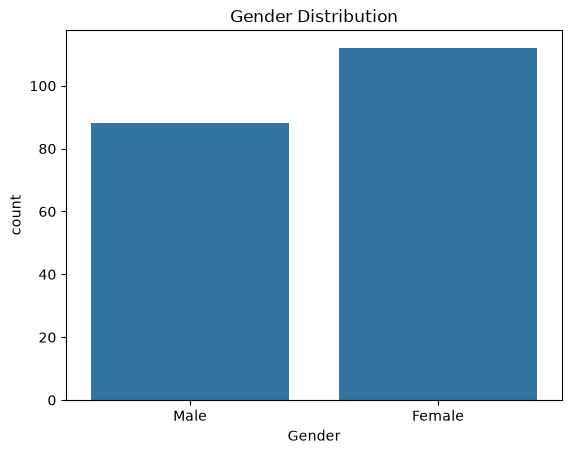

In [14]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

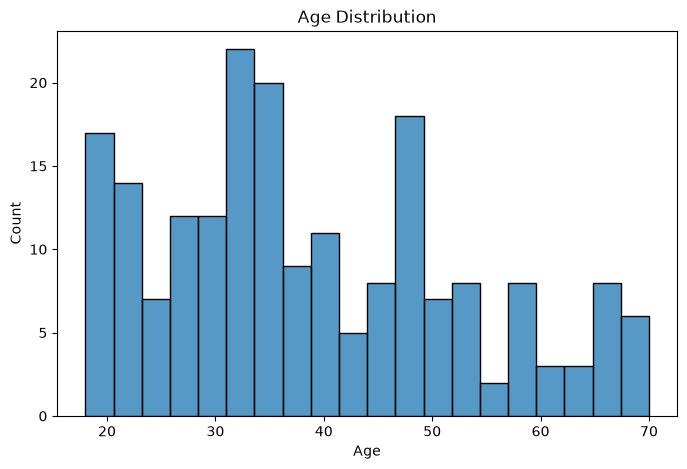

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

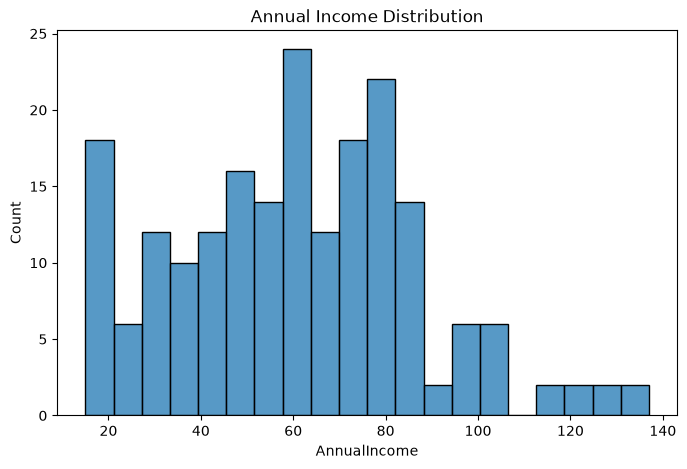

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["AnnualIncome"], bins=20)
plt.title("Annual Income Distribution")
plt.show()

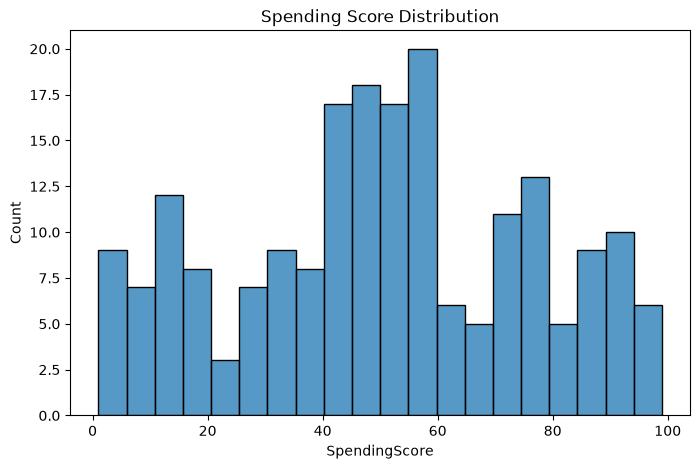

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["SpendingScore"], bins=20)
plt.title("Spending Score Distribution")
plt.show()

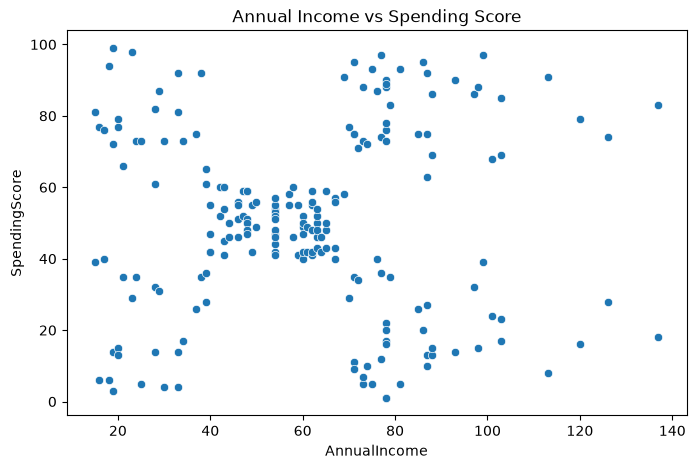

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="AnnualIncome",
    y="SpendingScore",
    data=df
)
plt.title("Annual Income vs Spending Score")
plt.show()

In [19]:
def segment(score):
    if score >= 80:
        return "Premium"
    elif score >= 60:
        return "Regular"
    elif score >= 40:
        return "Occasional"
    else:
        return "Low Value"

In [20]:
df["CustomerSegment"] = df["SpendingScore"].apply(segment)

In [21]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,CustomerSegment
0,1,Male,19,15,39,Low Value
1,2,Male,21,15,81,Premium
2,3,Female,20,16,6,Low Value
3,4,Female,23,16,77,Regular
4,5,Female,31,17,40,Occasional


In [22]:
df["CustomerSegment"].value_counts()

CustomerSegment
Occasional    76
Low Value     59
Regular       35
Premium       30
Name: count, dtype: int64

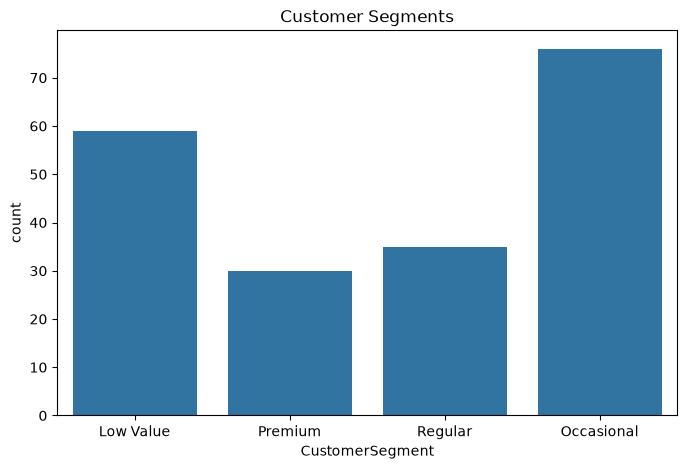

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x="CustomerSegment", data=df)
plt.title("Customer Segments")
plt.show()

In [24]:
df.to_csv("../dataset/customer_segmented.csv", index=False)

In [25]:
import sqlite3

conn = sqlite3.connect("../sql/customer.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully!")

Database created successfully!


In [26]:
pd.read_sql("""
SELECT *
FROM customers
LIMIT 5;
""", conn)

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,CustomerSegment
0,1,Male,19,15,39,Low Value
1,2,Male,21,15,81,Premium
2,3,Female,20,16,6,Low Value
3,4,Female,23,16,77,Regular
4,5,Female,31,17,40,Occasional


In [27]:
pd.read_sql("""
SELECT AVG(SpendingScore) AS AverageSpending
FROM customers;
""", conn)

,AverageSpending
0,50.2


In [28]:
pd.read_sql("""
SELECT Gender,
AVG(AnnualIncome) AS AverageIncome
FROM customers
GROUP BY Gender;
""", conn)

,Gender,AverageIncome
0,Female,59.250000
1,Male,62.227273


In [29]:
pd.read_sql("""
SELECT CustomerSegment,
COUNT(*) AS TotalCustomers
FROM customers
GROUP BY CustomerSegment;
""", conn)

,CustomerSegment,TotalCustomers
0,Low Value,59
1,Occasional,76
2,Premium,30
3,Regular,35


In [30]:
pd.read_sql("""
SELECT *
FROM customers
ORDER BY AnnualIncome DESC
LIMIT 10;
""", conn)

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,CustomerSegment
0,199,Male,32,137,18,Low Value
1,200,Male,30,137,83,Premium
2,197,Female,45,126,28,Low Value
3,198,Male,32,126,74,Regular
4,195,Female,47,120,16,Low Value
5,196,Female,35,120,79,Regular
6,193,Male,33,113,8,Low Value
7,194,Female,38,113,91,Premium
8,189,Female,41,103,17,Low Value
9,190,Female,36,103,85,Premium


In [31]:
pd.read_sql("""
SELECT CustomerSegment,
COUNT(*) AS TotalCustomers
FROM customers
GROUP BY CustomerSegment;
""", conn)

,CustomerSegment,TotalCustomers
0,Low Value,59
1,Occasional,76
2,Premium,30
3,Regular,35


In [32]:
pd.read_sql("""
SELECT *
FROM customers
ORDER BY AnnualIncome DESC
LIMIT 10;
""", conn)

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,CustomerSegment
0,199,Male,32,137,18,Low Value
1,200,Male,30,137,83,Premium
2,197,Female,45,126,28,Low Value
3,198,Male,32,126,74,Regular
4,195,Female,47,120,16,Low Value
5,196,Female,35,120,79,Regular
6,193,Male,33,113,8,Low Value
7,194,Female,38,113,91,Premium
8,189,Female,41,103,17,Low Value
9,190,Female,36,103,85,Premium


# Business Insights

## Key Findings

- Premium customers have the highest spending scores and should receive loyalty rewards.
- Low Value customers can be targeted with discounts and promotional offers.
- Annual income alone does not determine customer spending behavior.
- Customer segmentation helps businesses personalize marketing campaigns.
- Understanding customer segments can improve customer retention and increase sales.